# Machine Learning - Exercise 4
# Generative - Discriminative Classifiers


#Import 

Import libraries that contains the implementations of the functions used in the rest of the program.



In [1]:
import random
import numpy as np
import sklearn.metrics 
from sklearn.metrics import accuracy_score
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit, GridSearchCV
from sklearn import svm
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.multiclass import unique_labels
import matplotlib.pyplot as plt


print("Libraries imported.")

Libraries imported.


# Data set

## Load data

Load training data.

Choose one of the datasets described in the next subsections.

More details on these datasets are available in https://scikit-learn.org/stable/datasets/toy_dataset.html


In [2]:
dataset_name = "Iris" # "Iris", "Wines"

if dataset_name == "Iris":
  DB = datasets.load_iris()
elif dataset_name == "Wines":
  DB = datasets.load_wine()

class_names = np.array([str(c) for c in DB.target_names])
X_all = DB.data
y_all = DB.target

# print specs
print("Dataset: %s" %(dataset_name))

# [Iris] 150 samples x 4 features
print("Input shape: %s" %str(X_all.shape))

print("Output shape: %s" %str(y_all.shape))

# [Iris]
# 1. sepal length in cm
# 2. sepal width in cm
# 3. petal length in cm
# 4. petal width in cm
print("Number of attributes/features: %d" %(X_all.shape[1]))

print("Number of classes: %d %s" %(len(class_names), str(class_names)))

print("Number of samples: %d" %(X_all.shape[0]))

# show an example
id = random.randrange(0,X_all.shape[0])

print("Example:")
print("x%d = %r" %(id,X_all[id]))
print("y%d = %r ['%s']" %(id,y_all[id],class_names[y_all[id]]))

Dataset: Iris
Input shape: (150, 4)
Output shape: (150,)
Number of attributes/features: 4
Number of classes: 3 ['setosa' 'versicolor' 'virginica']
Number of samples: 150
Example:
x4 = array([5. , 3.6, 1.4, 0.2])
y4 = 0 ['setosa']


##Split data

Split the data set in training set `X_train`, `y_train` and test set `X_test`, `y_test`, using `test_size` to denote percentage of samples in the test set.

Note:
`random_state` parameter is used as random seed. Change this value to generate a different split.

IMPORTANT: solution will depend on this data split.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.333, 
                                                    random_state=15)

print("Size of training set: %d" %X_train.shape[0])
print("Size of test set: %d" %X_test.shape[0])

print('First training sample')
id = 0
print("    x_train_%d = %r" %(id,X_train[id]))
print("    y_train_%d = %r ['%s']" %(id,y_train[id],class_names[y_train[id]]))

print('First test sample')
id = 0
print("    x_test_%d = %r" %(id,X_test[id]))
print("    y_test_%d = %r ['%s']" %(id,y_test[id],class_names[y_test[id]]))


Size of training set: 100
Size of test set: 50
First training sample
    x_train_0 = array([5.7, 2.5, 5. , 2. ])
    y_train_0 = 2 ['virginica']
First test sample
    x_test_0 = array([4.6, 3.4, 1.4, 0.3])
    y_test_0 = 0 ['setosa']


## Reduce data set to two dimensions

Reduce feature dimensions to 2. We consider only a 2D input for visualizing the data generation capability of this model using 2D plots.

In [4]:
# select the first two features
X_train_reduced = X_train[:,0:2] # all the samples, for each one take only the first two features
X_test_reduced = X_test[:,0:2]
print("Input shape reduced train: %s" %str(X_train_reduced.shape))
print("Input shape reduced test: %s" %str(X_test_reduced.shape))

Input shape reduced train: (100, 2)
Input shape reduced test: (50, 2)


## Visualize data 

Visualize reduced training/test sets

Text(0.5, 1.0, 'Training and test samples')

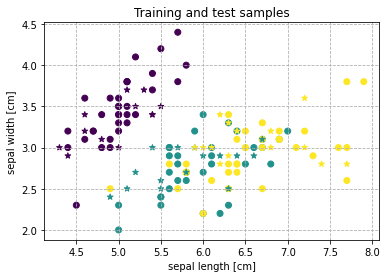

In [5]:
plt.figure()

# c can be 0, 1 or 2
plt.scatter(X_train_reduced[:,0], X_train_reduced[:,1], c=y_train)

# test samples are of the same colors (0, 1, 2), but identified with a star
plt.scatter(X_test_reduced[:,0], X_test_reduced[:,1], c=y_test, marker="*")

plt.grid(linestyle="--")
plt.xlabel('sepal length [cm]')
plt.ylabel('sepal width [cm]')
plt.title("Training and test samples")

# Probabilistic models

A probabilistic model computes the probability of each class c given the new sample x (and the dataset) $P(c_i | x)$. There are two ways to achieve this and thus two families of probabilistic models:

* generative models \\

  We estimate $P(x | c_i)$ and then apply the Bayes rule to compute $P(c_i | x)$:

  \begin{align}
    P(c_i | x) = \frac{P(x | c_i) P(c_i)}{P(x)}
  \end{align}

  It is very common to use a Gaussian ditribution $N$ to estimate $P(x | c_i)$ (Gaussian Naive Bayes).

* discriminative models \\

  We estimate $P(c_i | x)$ directly (Logistic Regression).

# Generative models

Gaussian Naive Bayes (https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html)


If $x \in R^d$ then the posterior probabilities $P(x | c_i)$ are continuous functions (domain $X$ is continuous). If we suppose that $P(x | c_i)$ is a Gaussian distribution, we have a Gaussian Naive Bayes probabilistic generative model.

  * Concept learning problem (two classes)

  If we suppose that the classes are completely disjoint (total probability rule):
  \begin{align}
      P(x) = P(x | c_1)P(c_1) + P(x | c_2)P(c_2)
  \end{align}

  So:

  \begin{align}
    P(c_1 | x) = \frac{P(x | c_1) P(c_1)}{P(x)} = \frac{P(x | c_1) P(c_1)}{P(x | c_1)P(c_1) + P(x | c_2)P(c_2)} \\
    P(c_2 | x) = \frac{P(x | c_2) P(c_2)}{P(x)} = \frac{P(x | c_2) P(c_2)}{P(x | c_1)P(c_1) + P(x | c_2)P(c_2)}
  \end{align}

  $P(c_2 | x) = 1 - P(c_1 | x)$ so we focus only on $P(c_1 | x)$. Developing the computations we have that:

  \begin{align}
    P(c_1 | x) = \frac{P(x | c_1) P(c_1)}{P(x | c_1)P(c_1) + P(x | c_2)P(c_2)} = \frac{1}{1 + e^{-a}} = σ(a)
  \end{align}

  where $σ(a)$ is called Sigmoid function, with

  \begin{align}
      a = \frac{P(c_1 | x)P(c_1)}{P(c_2 | x)P(c_2)}
  \end{align}

  From the above assumption (Probability distribution $P(x | c_i)$ is a Gaussian distribution) we have:

  \begin{align}
      P(x | c_i) = N(x, μ_i, Σ)
  \end{align}

  So:

  \begin{align}
      a = \frac{P(c_1 | x)P(c_1)}{P(c_2 | x)P(c_2)} = \frac{N(x, μ_1, Σ)P(c_1)}{N(x, μ_2, Σ)P(c_2)}
  \end{align}

* Classification problem (two or more classes)
 
  If we suppose that the classes are completely disjoint (total probability rule):
  \begin{align}
      P(x) = \sum_{j}P(x | c_j)P(c_j)
  \end{align}

  The model will be:

  \begin{align}
    P(c_k | x) = \frac{P(x | c_k) P(c_k)}{\sum_{j}P(x | c_j)P(c_j)} = \frac{e^{a_k}}{\sum_{j = 1}^{K} e^{a_j}} = σ(a)
  \end{align}

  where $σ(a)$ is called Softmax function, with 
  
  \begin{align}
    a = ln P(x | c_k)P(c_k)
  \end{align}

  \begin{align}
    k \in [1, ..., K]
  \end{align}

  From the above assumption (Probability distribution $P(x | c_i)$ is a Gaussian distribution) we have:

  \begin{align}
      P(x | c_i) = N(x, μ_i, Σ)
  \end{align}

  So:

  \begin{align}
      a = ln P(x | c_k)P(c_k) = ln N(x, μ_k, Σ)P(c_k)
  \end{align}

The SoftMax function is an extension of the Sigmoid function. The Sigmoid function receives just one input and only outputs a single number that represents the probability of belonging to $c_1$ (remember that we only have 2 classes so the probability of belonging to $c_2$ is $1 - P(c_1))$. While on the other hand SoftMax is vectorized, meaning that takes a vector with the same number of entries as classes we have and outputs another vector where each component represents the probability of belonging to that class.

<!--
Now that we have a way to compute $P(c_i | x)$, we need to compute the likelihood. Likelihood = probability of the output given the parameters of the model and the dataset. 

It involves maximizing a likelihood function in order to find the probability distribution and parameters that best explain the observed data.
-->

* How do you choose the probability distribution function?
* How do you choose the parameters for the probability distribution function?

In such classification problems, the fact that a particular class is the right outcome can be viewed as an hypothesis: $h_i$ corresponds to the event that class $c_i$ is the right outcome. Among all the hypotheses, we want the most probable one:

\begin{align}
  h^* = argmax_{h \in H} P(h | D) = argmax_{h \in H} \frac{P(D | h) P(h)}{P(D)} = argmax_{h \in H} P(D | h) P(h)
\end{align}

There are many techniques for solving this problem, although two common approaches are:

* Maximum a Posteriori (MAP), a Bayesian method.
* Maximum Likelihood Estimation (MLE), frequentist method.

The main difference is that MLE assumes that all solutions are equally likely beforehand, whereas MAP allows prior information about the form of the solution to be harnessed.

* we have prior information about the probability of an hypothesis $→$ MAP
* all the hypotheses have the same probability of occurring $→$ MLE

The classification problem becomes an optimization problem in which we need to find a particular set of parameters to assign to the probability distribution function (that, as we have seen, approximates $P(x | c_i)$) in order to have the maximum value (max probability). We then use the max probability to find the hypothesis to which it correspond.


In [6]:
gen_model = GaussianNB()

Fit generative model on reduced training data and print generative parameters:

> Means and standard deviations of fitted Gaussians are of dimension *(num_classes x num_features)*


In [7]:
gen_model.fit(X_train_reduced, y_train)
print("Means:", gen_model.theta_)
print("Means shape: ", gen_model.theta_.shape)
print("\n")
print("Standard deviations:", gen_model.var_)
print("Standard deviations shape: ", gen_model.var_.shape)

Means: [[5.02121212 3.47575758]
 [5.99393939 2.76666667]
 [6.57941176 2.92352941]]
Means shape:  (3, 2)


Standard deviations: [[0.1180349  0.16607897]
 [0.2532966  0.1240404 ]
 [0.4557526  0.1182699 ]]
Standard deviations shape:  (3, 2)


## Visualize generated data by generative model

Sample learnt Gaussian distributions and visualize them.

[What is a covariance ellipse?](https://www.visiondummy.com/2014/04/draw-error-ellipse-representing-covariance-matrix/)

Long story short:
the covariance ellipse is also called confidence ellipse. The error ellipse represents an iso-contour of the Gaussian distribution, and allows you to visualize a 2D confidence interval. 

In the example below we have a set of 2D normally distributed points. The confidence ellipse defines the region that contains 95% of all samples that can be drawn from the underlying Gaussian distribution.

In [8]:
def plot_ellipse(ax, mu, sigma, color="k", label=None):
    """
    Based on
    http://stackoverflow.com/questions/17952171/not-sure-how-to-fit-data-with-a-gaussian-python.
    """
    from matplotlib.patches import Ellipse
    # Compute eigenvalues and associated eigenvectors
    vals, vecs = np.linalg.eigh(sigma)

    # Compute "tilt" of ellipse using first eigenvector
    x, y = vecs[:, 0]
    theta = np.degrees(np.arctan2(y, x))

    # Eigenvalues give length of ellipse along each eigenvector
    w, h = 2 * np.sqrt(vals)

    ax.tick_params(axis='both', which='major', labelsize=20)
    ellipse = Ellipse(mu, w, h, theta, color=color, label=label)  # color="k")
    ellipse.set_clip_box(ax.bbox)
    ellipse.set_alpha(0.2)
    ax.add_artist(ellipse)
    return ellipse

900


Text(0.5, 1.0, 'Training and generated samples')

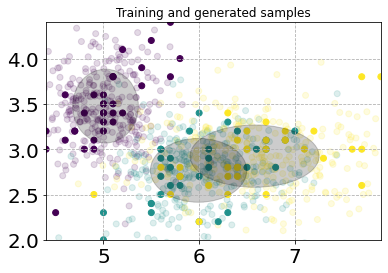

In [9]:
n_sampled_points = 300
sampled_data = []
sampled_labels = []

plt.figure()
for class_id in range(len(class_names)):

  # plot ellipse of gaussian distribution
  plot_ellipse(plt.gca(), gen_model.theta_[class_id], np.identity(2)*gen_model.var_[class_id])

  # point generation:
  # input (point) = gaussian(theta, covariance matrix, number of samples)
  x_sampled = np.random.multivariate_normal(gen_model.theta_[class_id], np.identity(2)*gen_model.var_[class_id], n_sampled_points)
  y_sampled = np.repeat(class_id, repeats=n_sampled_points)

  sampled_data.append(x_sampled)
  sampled_labels.append(y_sampled)

sampled_data = np.concatenate(sampled_data,axis=0)
sampled_labels = np.concatenate(sampled_labels,axis=0)

# plot generated data
plt.scatter(sampled_data[:,0], sampled_data[:,1], c=sampled_labels, alpha=0.15)

# plot training data
plt.scatter(X_train_reduced[:,0], X_train_reduced[:,1], c=y_train)

print(len(sampled_data))

plt.xlim(np.min(X_train_reduced[:,0]), np.max(X_train_reduced[:,0]))
plt.ylim(np.min(X_train_reduced[:,1]), np.max(X_train_reduced[:,1]))
plt.grid(linestyle="--")
plt.title("Training and generated samples")

Evaluate generative model in classification task

In [10]:
y_pred = gen_model.predict(X_test_reduced)
acc = accuracy_score(y_pred, y_test)    
print("Accuracy %.3f" %acc)

Accuracy 0.840


## Test generative model resistance to label noise

Noisy labels

Text(0.5, 1.0, 'Noisy training samples')

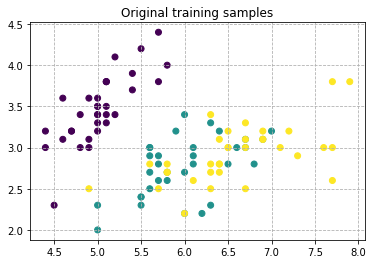

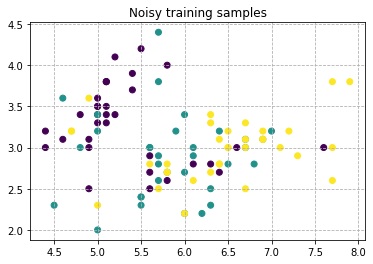

In [11]:
# randomly permute a percentage of training labels
percentage = 0.3

y_train_noisy = np.copy(y_train)

ix_size = int(percentage * len(y_train_noisy))
ix = np.random.choice(len(y_train_noisy), size=ix_size, replace=False)
b = y_train[ix]
np.random.shuffle(b)
y_train_noisy[ix] = b

# plot original training data
plt.figure()
plt.scatter(X_train_reduced[:,0], X_train_reduced[:,1], c=y_train)
plt.grid(linestyle="--")
plt.title("Original training samples")

# plot noisy training data

plt.figure()
plt.scatter(X_train_reduced[:,0], X_train_reduced[:,1], c=y_train_noisy)
plt.grid(linestyle="--")
plt.title("Noisy training samples")

Fit model to noisy labels

In [12]:
gen_model = GaussianNB()
gen_model.fit(X_train_reduced, y_train_noisy)
print("Means:", gen_model.theta_)
print("Means shape: ", gen_model.theta_.shape)
print("\n")
print("Standard deviations:", gen_model.var_)
print("Standard deviations shape: ", gen_model.var_.shape)

Means: [[5.35151515 3.28787879]
 [5.84242424 2.89090909]
 [6.40588235 2.98529412]]
Means shape:  (3, 2)


Standard deviations: [[0.42795225 0.21379247]
 [0.40850321 0.25052342]
 [0.67290658 0.13537197]]
Standard deviations shape:  (3, 2)


Visualize generated samples from noisy estimates

/usr/local/lib/python3.8/dist-packages/sklearn/utils/deprecation.py:103: FutureWarning: Attribute `sigma_` was deprecated in 1.0 and will be removed in1.2. Use `var_` instead.
  warnings.warn(msg, category=FutureWarning)


Text(0.5, 1.0, 'Original training and noisy generated samples')

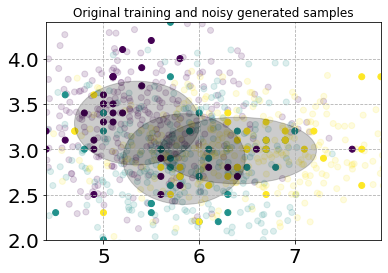

In [13]:
n_sampled_points = 300
sampled_data = []
sampled_labels = []

plt.figure()
for class_id in range(len(class_names)):

  # plot ellipse of gaussian distribution
  plot_ellipse(plt.gca(), gen_model.theta_[class_id], np.identity(2)*gen_model.sigma_[class_id])

  x_sampled = np.random.multivariate_normal(gen_model.theta_[class_id], np.identity(2)*gen_model.sigma_[class_id], n_sampled_points)
  y_sampled = np.repeat(class_id, repeats=n_sampled_points)
  sampled_data.append(x_sampled)
  sampled_labels.append(y_sampled)

sampled_data = np.concatenate(sampled_data,axis=0)
sampled_labels = np.concatenate(sampled_labels,axis=0)

# plot generated data
plt.scatter(sampled_data[:,0], sampled_data[:,1], c=sampled_labels, alpha=0.15)

# plot original training data
plt.scatter(X_train_reduced[:,0], X_train_reduced[:,1], c=y_train_noisy)

plt.xlim(np.min(X_train_reduced[:,0]), np.max(X_train_reduced[:,0]))
plt.ylim(np.min(X_train_reduced[:,1]), np.max(X_train_reduced[:,1]))
plt.grid(linestyle="--")
plt.title("Original training and noisy generated samples")

Evaluate generative model in classification task with noisy labels

In [14]:
y_pred = gen_model.predict(X_test_reduced)
acc = accuracy_score(y_pred, y_test)    
print("Accuracy %.3f" %acc)

Accuracy 0.880


# Discriminative model

# Logistic regression

In [15]:
discrim_model = LogisticRegression()

## Visualize decision boundaries of discriminant classifier


Reduce feature dimensions to 2. We consider only a 2D input for visualizing the decision boundaries of the classifier using 2D plots.

In [16]:
# select the first two features
X_train_reduced = X_train[:,0:2]
X_test_reduced = X_test[:,0:2]
print("Input shape reduced train: %s" %str(X_train_reduced.shape))
print("Input shape reduced test: %s" %str(X_test_reduced.shape))

Input shape reduced train: (100, 2)
Input shape reduced test: (50, 2)


Fit classifier on data

In [17]:
discrim_model.fit(X_train_reduced, y_train)

LogisticRegression()

Plot decision boundaries of each class versus other classes

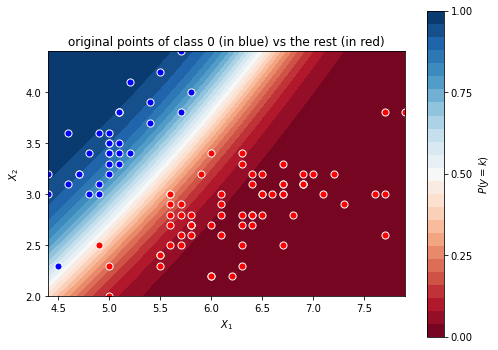

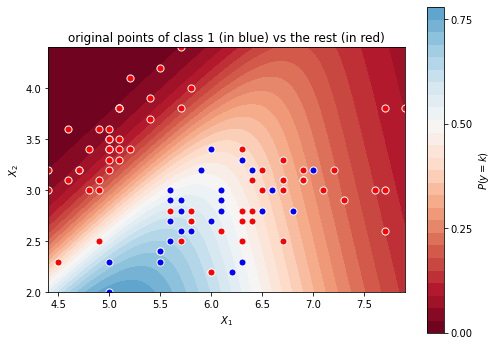

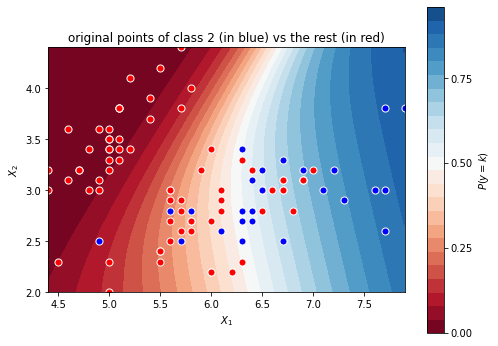

In [20]:
xx, yy = np.mgrid[np.min(X_train_reduced[:,0]):np.max(X_train_reduced[:,0]):.01, np.min(X_train_reduced[:,1]):np.max(X_train_reduced[:,1]):.01]
grid = np.c_[xx.ravel(), yy.ravel()]

for class_id in range(len(class_names)):
  # compute probability to belong to class class_id
  probs = discrim_model.predict_proba(grid)[:, class_id].reshape(xx.shape)

  f, ax = plt.subplots(figsize=(8, 6))
  contour = ax.contourf(xx, yy, probs, 25, cmap="RdBu", vmin=0, vmax=1)
  ax_c = f.colorbar(contour)
  ax_c.set_label("$P(y = k)$")
  ax_c.set_ticks([0, .25, .5, .75, 1])

  mask = y_train == class_id

  ax.scatter(X_train_reduced[mask,0], X_train_reduced[mask,1], c="b", s=50, vmin=-.2, vmax=1.2, edgecolor="w", linewidth=1)
  ax.scatter(X_train_reduced[np.logical_not(mask),0], X_train_reduced[np.logical_not(mask),1], c="r", s=50, vmin=-.2, vmax=1.2, edgecolor="w", linewidth=1)

  ax.set(aspect="equal",
        xlim=(np.min(X_train_reduced[:,0]), np.max(X_train_reduced[:,0])), ylim=(np.min(X_train_reduced[:,1]), np.max(X_train_reduced[:,1])),
        xlabel="$X_1$", ylabel="$X_2$")
  ax.set_title("original points of class {} (in blue) vs the rest (in red)".format(class_id))

Evaluate discriminative model on classification task

In [21]:
y_pred = discrim_model.predict(X_test_reduced)
acc = accuracy_score(y_pred, y_test)    
print("Accuracy %.3f" %acc)

Accuracy 0.860


##Test discriminative model resistance to label noise



Noisy labels

Text(0.5, 1.0, 'Noisy training samples')

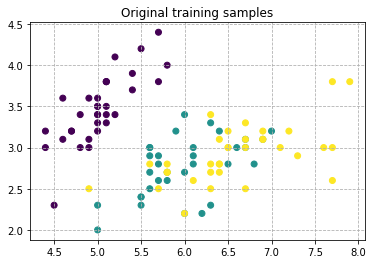

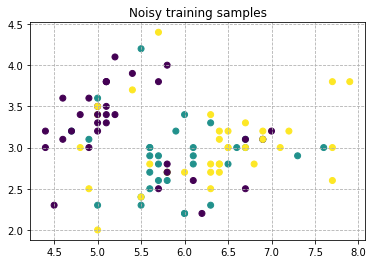

In [23]:
# randomly permute a percentage of training labels
percentage = 0.3

y_train_noisy = np.copy(y_train)

ix_size = int(percentage * len(y_train_noisy))
ix = np.random.choice(len(y_train_noisy), size=ix_size, replace=False)
b = y_train[ix]
np.random.shuffle(b)
y_train_noisy[ix] = b

# plot original training data
plt.figure()
plt.scatter(X_train_reduced[:,0], X_train_reduced[:,1], c=y_train)
plt.grid(linestyle="--")
plt.title("Original training samples")

# plot noisy training data
plt.figure()
plt.scatter(X_train_reduced[:,0], X_train_reduced[:,1], c=y_train_noisy)
plt.grid(linestyle="--")
plt.title("Noisy training samples")

Fit model to noisy labels

In [24]:
discrim_model = LogisticRegression()
discrim_model.fit(X_train_reduced, y_train_noisy)

LogisticRegression()

Visualize noisy decision boundaries

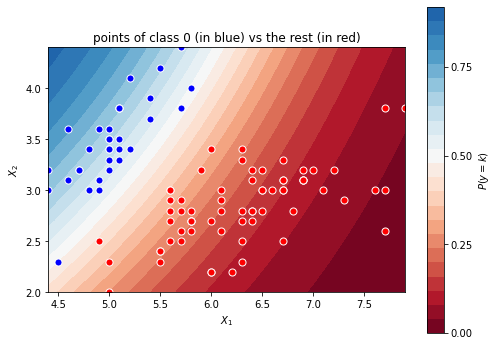

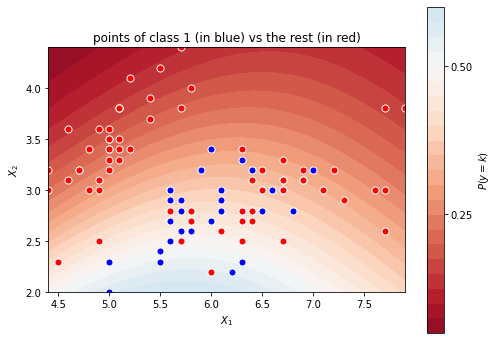

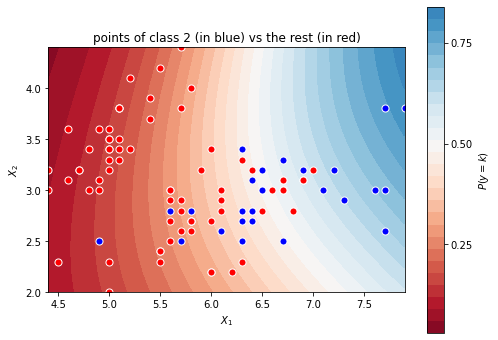

In [25]:
xx, yy = np.mgrid[np.min(X_train_reduced[:,0]):np.max(X_train_reduced[:,0]):.01, np.min(X_train_reduced[:,1]):np.max(X_train_reduced[:,1]):.01]
grid = np.c_[xx.ravel(), yy.ravel()]

for class_id in range(len(class_names)):
  # compute probability to belong to class class_id
  probs = discrim_model.predict_proba(grid)[:, class_id].reshape(xx.shape)

  f, ax = plt.subplots(figsize=(8, 6))
  contour = ax.contourf(xx, yy, probs, 25, cmap="RdBu", vmin=0, vmax=1)
  ax_c = f.colorbar(contour)
  ax_c.set_label("$P(y = k)$")
  ax_c.set_ticks([0, .25, .5, .75, 1])

  mask = y_train == class_id

  ax.scatter(X_train_reduced[mask,0], X_train_reduced[mask,1], c="b", s=50, vmin=-.2, vmax=1.2, edgecolor="w", linewidth=1)
  ax.scatter(X_train_reduced[np.logical_not(mask),0], X_train_reduced[np.logical_not(mask),1], c="r", s=50, vmin=-.2, vmax=1.2, edgecolor="w", linewidth=1)

  ax.set(aspect="equal",
        xlim=(np.min(X_train_reduced[:,0]), np.max(X_train_reduced[:,0])), ylim=(np.min(X_train_reduced[:,1]), np.max(X_train_reduced[:,1])),
        xlabel="$X_1$", ylabel="$X_2$")
  ax.set_title("points of class {} (in blue) vs the rest (in red)".format(class_id))

Evaluate discriminative model on classification task

In [26]:
y_pred = discrim_model.predict(X_test_reduced)
acc = accuracy_score(y_pred, y_test)    
print("Accuracy %.3f" %acc)

Accuracy 0.840


# Home Exercises

Consider all the datasets proposed in this exercise with all input features.

**Question 1**

Compare the performance of both models considering different percentages of noisy labels. Plot performace (e.g., accuracy) over percentage of noisy labels,condsidering percentage values 0.0, 0.25, 0.5, 0.75, 1.

**Question 2** 

Compare the performance of both models considering different percentages of random samples, i.e., samples randomly gathered from random distributions and assigned to each class. 
Plot performace (e.g., accuracy) over percentage of random samples, condsidering percentage values 0.0, 0.25, 0.5, 0.75, 1.
